Data loaded successfully!


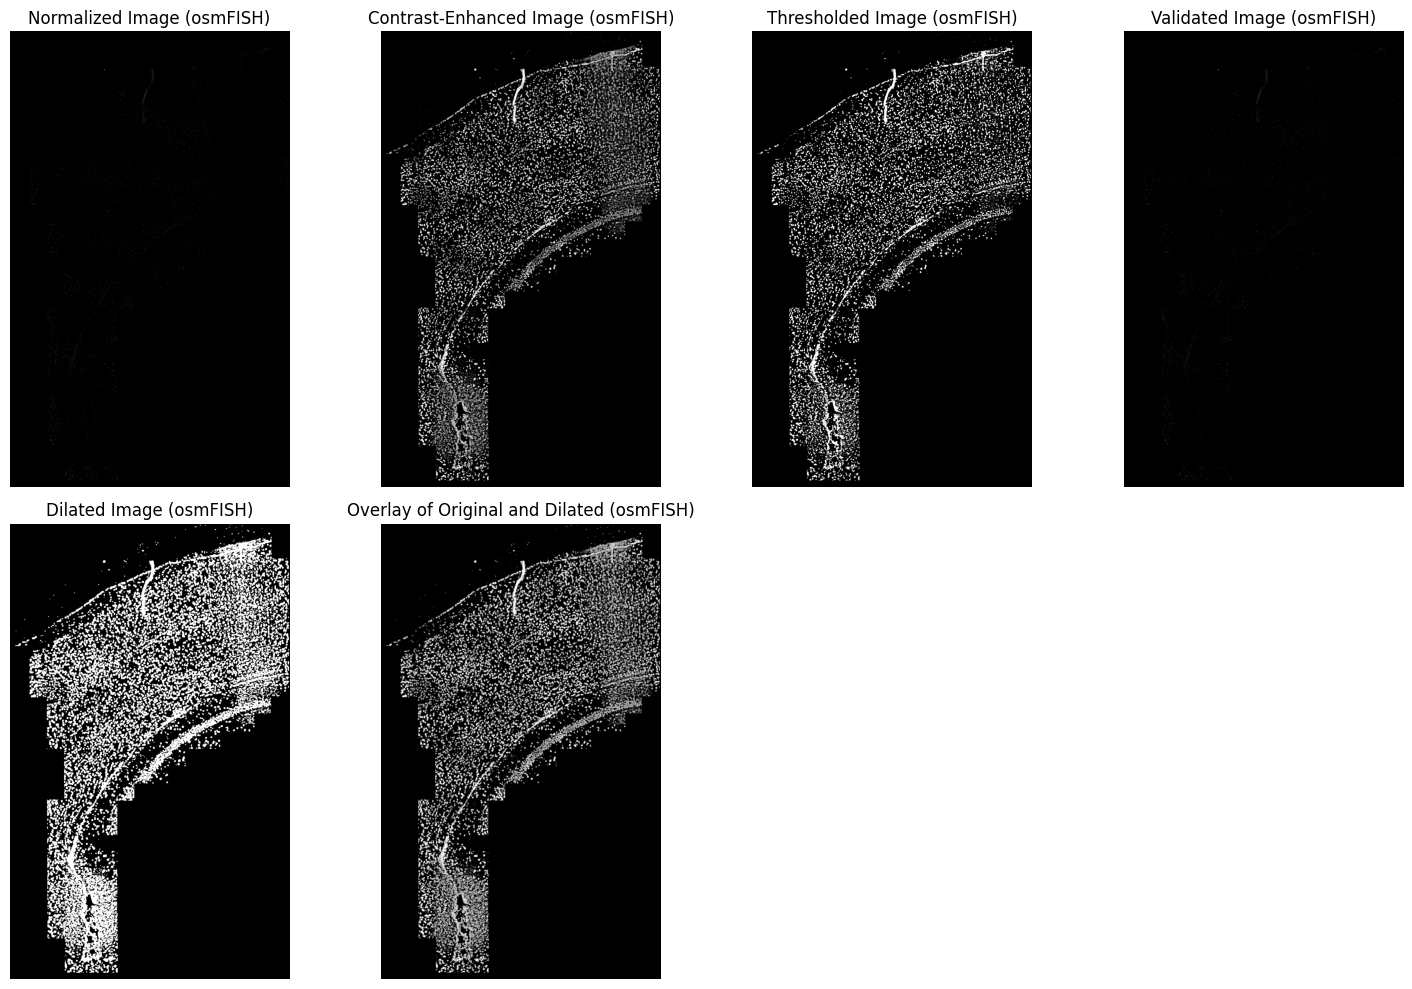

In [16]:
import pickle
import numpy as np
import cv2  # OpenCV for image processing
import matplotlib.pyplot as plt

# Step 1: Load the nuclei image data
file_to_load = "/kaggle/input/merfish-multiplexed-smfish-osmfish-3dataset/supplemental_data_ssam_2019/osmFISH/raw_data/im_nuc_small.pickle"
with open(file_to_load, 'rb') as f:
    nuclei_data = pickle.load(f)

print("Data loaded successfully!")

# Step 2: Normalize the data to the 0-255 range
normalized_image = ((nuclei_data - nuclei_data.min()) / (nuclei_data.max() - nuclei_data.min()) * 255).astype('uint8')

# Step 3: Enhance contrast using histogram equalization
enhanced_image = cv2.equalizeHist(normalized_image)

# Step 4: Apply binary thresholding to segment the nuclei
threshold_value = 128  # You can adjust this value as needed
_, binary_mask = cv2.threshold(enhanced_image, threshold_value, 255, cv2.THRESH_BINARY)

# Step 5: Validate the results by multiplying the original grayscale image with the binary mask
validated_image = cv2.bitwise_and(normalized_image, normalized_image, mask=binary_mask)

# Step 6: Apply dilation to enhance nuclei regions
kernel = np.ones((5, 5), np.uint8)  # Adjust kernel size if needed
dilated_image = cv2.dilate(binary_mask, kernel, iterations=1)

# Step 7: Create an overlay of the original enhanced image and the dilated mask
overlay = cv2.addWeighted(enhanced_image, 0.7, dilated_image, 0.3, 0)

# Visualization
plt.figure(figsize=(15, 10))

# Original Normalized Image
plt.subplot(2, 4, 1)
plt.imshow(normalized_image, cmap='gray')
plt.title("Normalized Image (osmFISH)")
plt.axis('off')

# Contrast-Enhanced Image
plt.subplot(2, 4, 2)
plt.imshow(enhanced_image, cmap='gray')
plt.title("Contrast-Enhanced Image (osmFISH)")
plt.axis('off')

# Thresholded Image
plt.subplot(2, 4, 3)
plt.imshow(binary_mask, cmap='gray')
plt.title("Thresholded Image (osmFISH)")
plt.axis('off')

# Validated Image
plt.subplot(2, 4, 4)
plt.imshow(validated_image, cmap='gray')
plt.title("Validated Image (osmFISH)")
plt.axis('off')

# Dilated Image
plt.subplot(2, 4, 5)
plt.imshow(dilated_image, cmap='gray')
plt.title("Dilated Image (osmFISH)")
plt.axis('off')

# Overlay Image
plt.subplot(2, 4, 6)
plt.imshow(overlay, cmap='gray')
plt.title("Overlay of Original and Dilated (osmFISH)")
plt.axis('off')

plt.tight_layout()
plt.show()


Data loaded successfully!


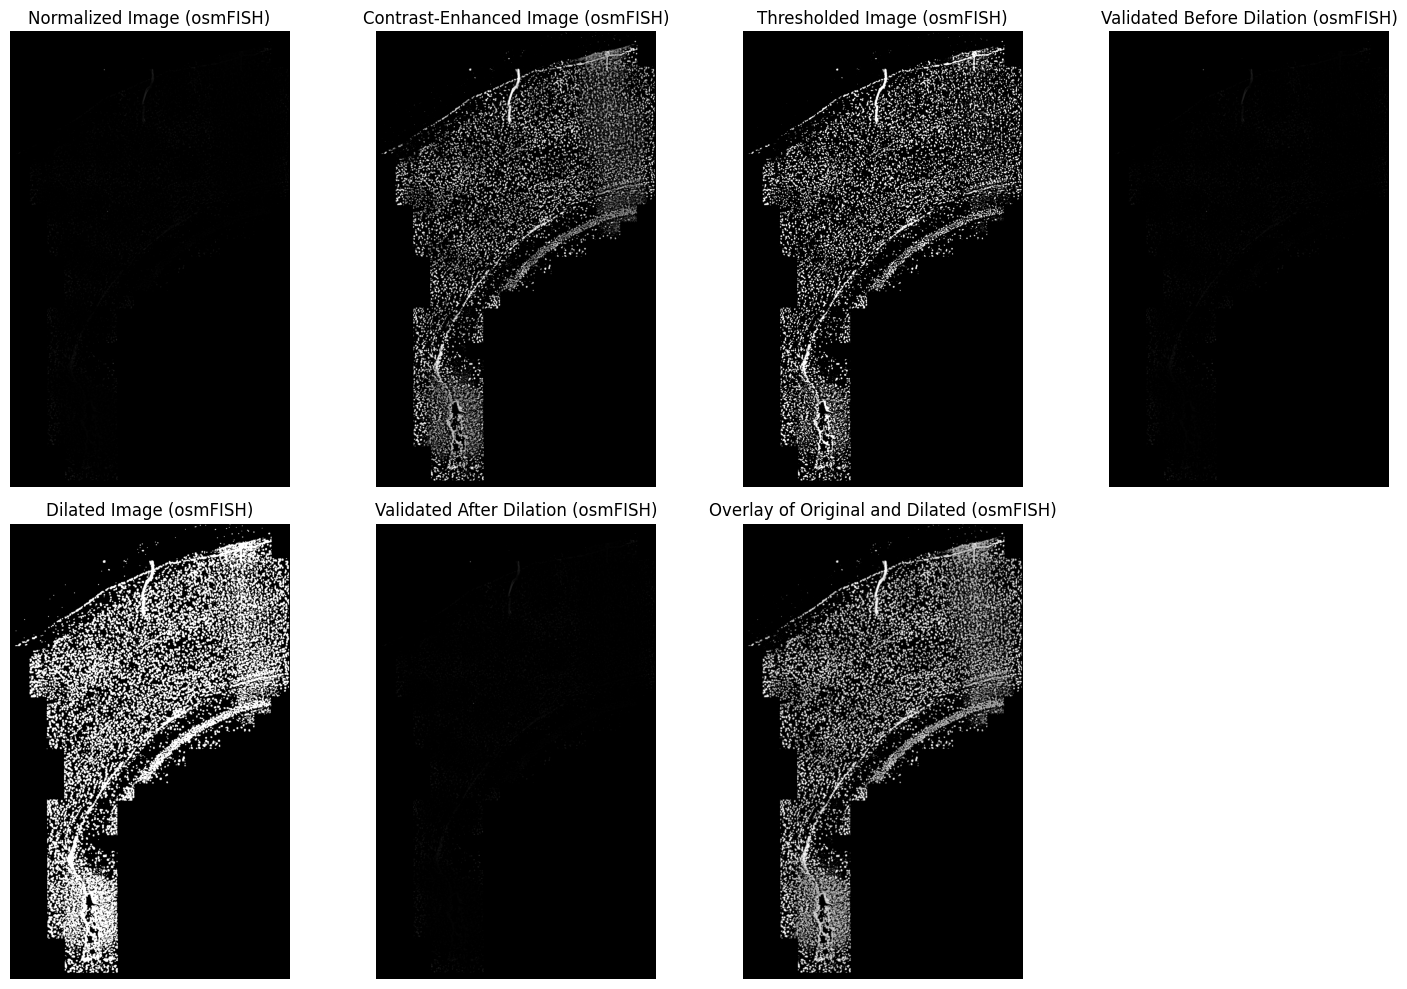

In [17]:
import pickle
import numpy as np
import cv2  # OpenCV for image processing
import matplotlib.pyplot as plt

# Step 1: Load the nuclei image data
file_to_load = "/kaggle/input/merfish-multiplexed-smfish-osmfish-3dataset/supplemental_data_ssam_2019/osmFISH/raw_data/im_nuc_small.pickle"
with open(file_to_load, 'rb') as f:
    nuclei_data = pickle.load(f)

print("Data loaded successfully!")

# Step 2: Normalize the data to the 0-255 range
normalized_image = ((nuclei_data - nuclei_data.min()) / (nuclei_data.max() - nuclei_data.min()) * 255).astype('uint8')

# Step 3: Enhance contrast using histogram equalization
enhanced_image = cv2.equalizeHist(normalized_image)

# Step 4: Apply binary thresholding to segment the nuclei
threshold_value = 128  # You can adjust this value as needed
_, binary_mask = cv2.threshold(enhanced_image, threshold_value, 255, cv2.THRESH_BINARY)

# Step 5: Validate the results before dilation (optional)
validated_before_dilation = cv2.bitwise_and(normalized_image, normalized_image, mask=binary_mask)

# Step 6: Apply dilation to enhance nuclei regions
kernel = np.ones((5, 5), np.uint8)  # Adjust kernel size if needed
dilated_image = cv2.dilate(binary_mask, kernel, iterations=1)

# Step 7: Validate the results after dilation
validated_after_dilation = cv2.bitwise_and(normalized_image, normalized_image, mask=dilated_image)

# Step 8: Create an overlay of the original enhanced image and the dilated mask
overlay = cv2.addWeighted(enhanced_image, 0.7, dilated_image, 0.3, 0)

# Visualization
plt.figure(figsize=(15, 10))

# Original Normalized Image
plt.subplot(2, 4, 1)
plt.imshow(normalized_image, cmap='gray')
plt.title("Normalized Image (osmFISH)")
plt.axis('off')

# Contrast-Enhanced Image
plt.subplot(2, 4, 2)
plt.imshow(enhanced_image, cmap='gray')
plt.title("Contrast-Enhanced Image (osmFISH)")
plt.axis('off')

# Thresholded Image
plt.subplot(2, 4, 3)
plt.imshow(binary_mask, cmap='gray')
plt.title("Thresholded Image (osmFISH)")
plt.axis('off')

# Validated Image Before Dilation
plt.subplot(2, 4, 4)
plt.imshow(validated_before_dilation, cmap='gray')
plt.title("Validated Before Dilation (osmFISH)")
plt.axis('off')

# Dilated Image
plt.subplot(2, 4, 5)
plt.imshow(dilated_image, cmap='gray')
plt.title("Dilated Image (osmFISH)")
plt.axis('off')

# Validated Image After Dilation
plt.subplot(2, 4, 6)
plt.imshow(validated_after_dilation, cmap='gray')
plt.title("Validated After Dilation (osmFISH)")
plt.axis('off')

# Overlay Image
plt.subplot(2, 4, 7)
plt.imshow(overlay, cmap='gray')
plt.title("Overlay of Original and Dilated (osmFISH)")
plt.axis('off')

plt.tight_layout()
plt.show()
